## Low rank solutions
This notebook looks at different low-rank solutions:
 - How does the the max rank $r$ affect $X_r$?
 - How does different sources interact with $r$?
 - How is convergence of DLRA-CG (early stopping)?

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params

def plot2(x, pb, *args, **kwargs):
    f = Function(pb['V_h'])
    f.vector()[:] = x
    plot(f, *args, **kwargs)

def plot_multiple_f(f_list, pid, names=None, fig_name=None, shrink=0, labels=None):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    PBP = PROBLEM_PARAMS[pid]
    width, height = PBP['width'], PBP['height']
    x0s, y0s = PBP['x0'], PBP['y0']

    fig, axes = plt.subplots(2, 2, figsize=(6, 6))

    if labels is None:
        labels = ['' for _ in f_list]
    
    for ax, func, l in zip(axes.flat, f_list, labels):
        plt.sca(ax)
        p = plot(func, title=None, cmap=CMAP)
        if shrink != 0: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(l)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)
    
    plt.tight_layout()
    save_plot(fig_name=fig_name)
    plt.show()

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Converged at iter 18 [rel_res=6.32e-17]
Converged at iter 18 [rel_res=5.57e-17]
Converged at iter 18 [rel_res=5.6e-17]0


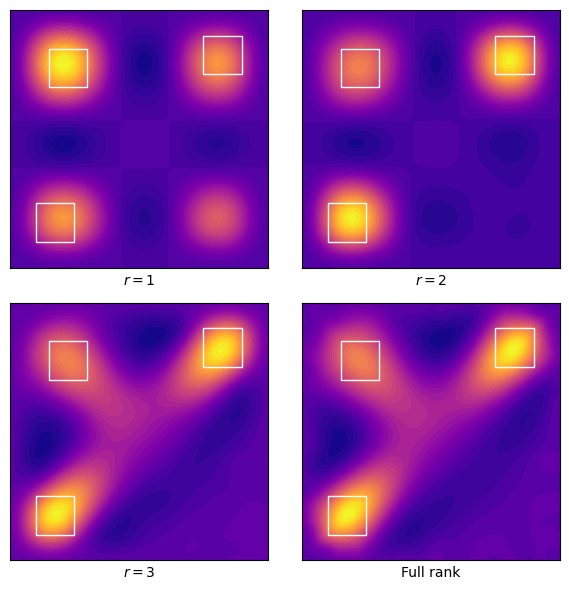

In [16]:


def selected_r(pid, r_list, lam, precond, k=50, rtol=1e-8, etol=None):
    """For a selected pid and r_list, plot the solutions"""
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd.solve(k=k)
    w = rsvd.weights()

    solver = DynamicalLowRankPCG(rsvd, pb['x'])

    labels = [f'$r={r}$' for r in r_list]
    labels.append('Full rank')

    f_list, errors = [], []
    r_list = [1, 2, 5]
    for r in r_list:
        x = solver.solve(
            pb['y'], w, lambda_=lam, max_rank=r, preconditioner=precond, rtol=rtol, etol=etol,
            max_iter=500
        )
        f = Function(pb['V_h'])
        f.vector()[:] = x

        f_list.append(f)
        errors.append(solver.error.copy())
        
    x_full_rank = rsvd.tikhonov_solve(pb['y'], w, lam=lam)
    f_full_rank = Function(pb['V_h'])
    f_full_rank.vector()[:] = x_full_rank
    f_list.append(f_full_rank)

    plot_multiple_f(f_list, pid=pid, labels=labels)
    return errors

r_list = [1, 2, 3]
errors = selected_r('II', r_list, lam=1e-4, precond='ic', k=50, rtol=1e-16, etol=0)

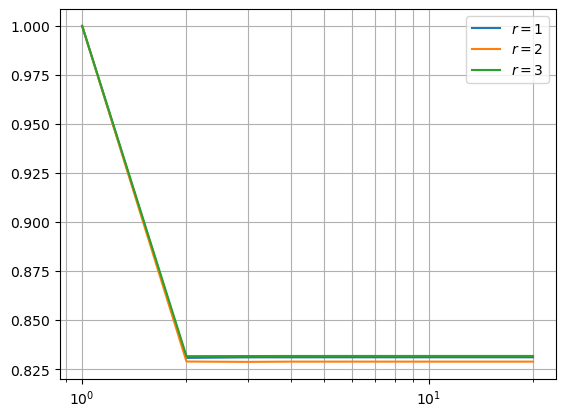

In [3]:
names = [f'$r={r}$' for r in r_list]
for i, e in enumerate(errors):
    #e = e[:10]
    plt.semilogx(np.arange(1,len(e)+1), e, label=names[i])
plt.grid(which='both')
plt.legend()